# Week 3: Linear Systems


In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

def gauss_eliminate(A, b, pivoting=False):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)
    if pivoting:
        for i in range(n):
            max_idx = i + np.argmax(np.abs(A[i:, i]))
            if max_idx != i:
                A[[i, max_idx]] = A[[max_idx, i]]
                b[[i, max_idx]] = b[[max_idx, i]]
            for j in range(i + 1, n):
                factor = A[j, i] / A[i, i]
                A[j, i:] -= factor * A[i, i:]
                b[j] -= factor * b[i]
    else:
        for i in range(n):
            for j in range(i + 1, n):
                factor = A[j, i] / A[i, i]
                A[j, i:] -= factor * A[i, i:]
                b[j] -= factor * b[i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i + 1:], x[i + 1:])) / A[i, i]
    return x

def lu_decompose(A):
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        for k in range(i, n):
            s = sum(L[i][j] * U[j][k] for j in range(i))
            U[i][k] = A[i][k] - s
        for k in range(i + 1, n):
            s = sum(L[k][j] * U[j][i] for j in range(i))
            L[k][i] = (A[k][i] - s) / U[i][i]
    return L, U

def forward_sub(L, b):
    b = b.astype(float)
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    return y

def back_sub(U, y):
    y = y.astype(float)
    n = len(y)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    return x

def thomas(A, d):
    n = len(d)
    a = np.zeros(n)
    b_diag = np.zeros(n)
    c = np.zeros(n)
    for i in range(n):
        b_diag[i] = A[i, i]
        if i > 0:
            a[i] = A[i, i - 1]
        if i < n - 1:
            c[i] = A[i, i + 1]
    c_star = np.zeros(n)
    d_star = np.zeros(n)
    c_star[0] = c[0] / b_diag[0]
    d_star[0] = d[0] / b_diag[0]
    for i in range(1, n):
        denom = b_diag[i] - a[i] * c_star[i - 1]
        if i < n - 1:
            c_star[i] = c[i] / denom
        d_star[i] = (d[i] - a[i] * d_star[i - 1]) / denom
    x = np.zeros(n)
    x[-1] = d_star[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_star[i] - c_star[i] * x[i + 1]
    return x

def jacobi(A, b, x0=None, tol=1e-8, max_iter=500):
    n = len(b)
    if x0 is None:
        x0 = np.zeros(n)
    x = x0.astype(float).copy()
    D = np.diag(A)
    R = A - np.diag(D)
    history = []
    for it in range(max_iter):
        x_new = (b - np.dot(R, x)) / D
        rel_err = np.linalg.norm(x_new - x) / (np.linalg.norm(x_new) + 1e-15)
        history.append(rel_err)
        if rel_err < tol:
            return x_new, it + 1, history
        x = x_new
    return x, max_iter, history

def gauss_seidel(A, b, x0=None, tol=1e-8, max_iter=500):
    n = len(b)
    if x0 is None:
        x0 = np.zeros(n)
    x = x0.astype(float).copy()
    history = []
    for it in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            s1 = np.dot(A[i, :i], x[:i])
            s2 = np.dot(A[i, i + 1:], x_old[i + 1:])
            x[i] = (b[i] - s1 - s2) / A[i, i]
        rel_err = np.linalg.norm(x - x_old) / (np.linalg.norm(x) + 1e-15)
        history.append(rel_err)
        if rel_err < tol:
            return x, it + 1, history
    return x, max_iter, history


### Problem 1: Solvent Blend Mass Balances

**System Setup:**
- Unknowns: $m_1, m_2, m_3$ (masses in kg of Stream 1, Stream 2, Stream 3).
- Total product mass = $100\text{ kg}$.

**Component Balances:**
- Component A (Row 1): $0.50 m_1 + 0.20 m_2 + 0.10 m_3 = 0.30 \times 100 = 30$
- Component B (Row 2): $0.30 m_1 + 0.50 m_2 + 0.20 m_3 = 0.40 \times 100 = 40$
- Component C (Row 3): $0.20 m_1 + 0.30 m_2 + 0.70 m_3 = 0.30 \times 100 = 30$

$$\begin{bmatrix} 0.50 & 0.20 & 0.10 \\ 0.30 & 0.50 & 0.20 \\ 0.20 & 0.30 & 0.70 \end{bmatrix} \begin{bmatrix} m_1 \\ m_2 \\ m_3 \end{bmatrix} = \begin{bmatrix} 30 \\ 40 \\ 30 \end{bmatrix}$$


In [2]:
A = np.array([
    [0.5, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.2, 0.3, 0.7]
])
b = np.array([30.0, 40.0, 30.0])

x = np.linalg.solve(A, b)
res = np.linalg.norm(A @ x - b)
total_mass = np.sum(x)

assert np.allclose(A @ x, b)
assert np.isclose(total_mass, 100.0)

print(f"Stream masses (kg): m1 = {x[0]:.4f}, m2 = {x[1]:.4f}, m3 = {x[2]:.4f}")
print(f"Residual norm: {res:.4e}")
print(f"Verified total mass: {total_mass:.4f} kg")


Stream masses (kg): m1 = 36.3636, m2 = 54.5455, m3 = 9.0909
Residual norm: 5.0243e-15
Verified total mass: 100.0000 kg


### Problem 2: Hand-Coded Gaussian Elimination vs Library Solve

**System Setup:**
- Unknowns: $x_1, x_2, x_3$.
- Equations:
  - Row 1: $2 x_1 + x_2 - x_3 = 8$
  - Row 2: $-3 x_1 - x_2 + 2 x_3 = -11$
  - Row 3: $-2 x_1 + x_2 + 2 x_3 = -3$

$$\begin{bmatrix} 2 & 1 & -1 \\ -3 & -1 & 2 \\ -2 & 1 & 2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} 8 \\ -11 \\ -3 \end{bmatrix}$$

**Hand Elimination & Multipliers:**
1. Multipliers for column 1:
   - $m_{21} = -3/2 = -1.5 \implies \text{Row 2} \leftarrow \text{Row 2} - (-1.5)\text{Row 1} = [0, 0.5, 0.5 | 1]$
   - $m_{31} = -2/2 = -1.0 \implies \text{Row 3} \leftarrow \text{Row 3} - (-1.0)\text{Row 1} = [0, 2, 1 | 5]$
2. Multiplier for column 2:
   - $m_{32} = 2 / 0.5 = 4.0 \implies \text{Row 3} \leftarrow \text{Row 3} - 4.0\text{Row 2} = [0, 0, -1 | 1]$

**Upper Triangular Matrix:**
$$\begin{bmatrix} 2 & 1 & -1 \\ 0 & 0.5 & 0.5 \\ 0 & 0 & -1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} 8 \\ 1 \\ 1 \end{bmatrix}$$

**Back-substitution:**
- $-x_3 = 1 \implies x_3 = -1$
- $0.5 x_2 + 0.5(-1) = 1 \implies x_2 = 3$
- $2 x_1 + 3 - (-1) = 8 \implies x_1 = 2$


In [3]:
A = np.array([
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
], dtype=float)
b = np.array([8, -11, -3], dtype=float)

x_hand = gauss_eliminate(A, b, pivoting=False)
x_builtin = np.linalg.solve(A, b)
res = b - A @ x_hand

assert np.allclose(x_hand, x_builtin)
assert np.allclose(A @ x_hand, b)

print(f"Hand-coded solution: {x_hand}")
print(f"Library solution:    {x_builtin}")
print(f"Residual vector:     {res}")


Hand-coded solution: [ 2.  3. -1.]
Library solution:    [ 2.  3. -1.]
Residual vector:     [0. 0. 0.]


### Problem 3: Chemical Reaction Balancing

**System Setup:**
- Reaction: $\text{C}_3\text{H}_8 + b \text{O}_2 \rightarrow c \text{CO}_2 + d \text{H}_2\text{O}$
- Unknowns: $b, c, d$ (with fuel coefficient fixed at 1).

**Atom Balances:**
- Carbon (C, Row 1): $c = 3 \implies 0 b + 1 c + 0 d = 3$
- Hydrogen (H, Row 2): $2 d = 8 \implies 0 b + 0 c + 2 d = 8$
- Oxygen (O, Row 3): $2 b = 2 c + d \implies 2 b - 2 c - 1 d = 0$

$$\begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 2 \\ 2 & -2 & -1 \end{bmatrix} \begin{bmatrix} b \\ c \\ d \end{bmatrix} = \begin{bmatrix} 3 \\ 8 \\ 0 \end{bmatrix}$$


In [4]:
A = np.array([
    [0, 1, 0],
    [0, 0, 2],
    [2, -2, -1]
], dtype=float)
b = np.array([3, 8, 0], dtype=float)

x = np.linalg.solve(A, b)
res = A @ x - b
b_coeff, c_coeff, d_coeff = x

assert np.allclose(A @ x, b)
assert np.isclose(3, c_coeff)
assert np.isclose(8, 2 * d_coeff)
assert np.isclose(2 * b_coeff, 2 * c_coeff + d_coeff)

print(f"Stoichiometric coefficients: b = {b_coeff:.1f}, c = {c_coeff:.1f}, d = {d_coeff:.1f}")
print(f"Balanced equation: C3H8 + {b_coeff:.0f} O2 -> {c_coeff:.0f} CO2 + {d_coeff:.0f} H2O")
print(f"Residual norm: {np.linalg.norm(res):.4e}")


Stoichiometric coefficients: b = 5.0, c = 3.0, d = 4.0
Balanced equation: C3H8 + 5 O2 -> 3 CO2 + 4 H2O
Residual norm: 0.0000e+00


### Problem 4: Parallel Pipe Network Flow

**System Setup:**
- Unknowns: $Q_1, Q_2, Q_3$ (flow rates in L/s).
- Resistances: $R_1 = 2, R_2 = 3, R_3 = 4 \text{ kPa}\cdot\text{s/L}$.
- Pressure drop: $\Delta P = R_i Q_i$.

**Equations:**
- Continuity (Row 1): $Q_1 + Q_2 + Q_3 = 12$
- Equal $\Delta P$ ($1 \& 2$, Row 2): $2 Q_1 - 3 Q_2 + 0 Q_3 = 0$
- Equal $\Delta P$ ($2 \& 3$, Row 3): $0 Q_1 + 3 Q_2 - 4 Q_3 = 0$

$$\begin{bmatrix} 1 & 1 & 1 \\ 2 & -3 & 0 \\ 0 & 3 & -4 \end{bmatrix} \begin{bmatrix} Q_1 \\ Q_2 \\ Q_3 \end{bmatrix} = \begin{bmatrix} 12 \\ 0 \\ 0 \end{bmatrix}$$


In [5]:
A = np.array([
    [1, 1, 1],
    [2, -3, 0],
    [0, 3, -4]
], dtype=float)
b = np.array([12, 0, 0], dtype=float)

Q = np.linalg.solve(A, b)
dp = np.array([2 * Q[0], 3 * Q[1], 4 * Q[2]])

assert np.allclose(A @ Q, b)
assert np.allclose(dp[0], dp[1]) and np.allclose(dp[1], dp[2])
assert Q[0] > Q[1] > Q[2]

print(f"Flow rates (L/s): Q1 = {Q[0]:.4f}, Q2 = {Q[1]:.4f}, Q3 = {Q[2]:.4f}")
print(f"Branch pressure drops (kPa): DP1 = {dp[0]:.4f}, DP2 = {dp[1]:.4f}, DP3 = {dp[2]:.4f}")
print(f"Lowest-resistance branch (R1=2) carries most flow: {Q[0]:.4f} L/s")


Flow rates (L/s): Q1 = 5.5385, Q2 = 3.6923, Q3 = 2.7692
Branch pressure drops (kPa): DP1 = 11.0769, DP2 = 11.0769, DP3 = 11.0769
Lowest-resistance branch (R1=2) carries most flow: 5.5385 L/s


### Problem 5: Linear Independence and Singularity Analysis

**System Setup:**
- Matrix $A$ rows: $(1, 2, -1), (2, 4, -2), (3, 1, 0)$.

$$A = \begin{bmatrix} 1 & 2 & -1 \\ 2 & 4 & -2 \\ 3 & 1 & 0 \end{bmatrix}$$

**Physical & Mathematical Analysis:**
- Row 2 is exactly $2 \times \text{Row 1}$.
- The equations are linearly dependent ($\det(A) = 0$).
- Physically on a flowsheet, Row 2 provides no new independent balance information.
- `np.linalg.solve` will fail with a `LinAlgError` because $A$ is singular.


In [6]:
A = np.array([
    [1, 2, -1],
    [2, 4, -2],
    [3, 1, 0]
], dtype=float)
b = np.zeros(3)

det_A = np.linalg.det(A)

print(f"Determinant of A: {det_A:.4f}")
assert np.isclose(det_A, 0.0)

try:
    x = np.linalg.solve(A, b)
    print(x)
except np.linalg.LinAlgError as e:
    print(f"Diagnosis: {e} -> Matrix is singular due to linearly dependent rows (Row 2 = 2 * Row 1).")


Determinant of A: 0.0000
Diagnosis: Singular matrix -> Matrix is singular due to linearly dependent rows (Row 2 = 2 * Row 1).


### Problem 6: Danger of Tiny Pivots and Partial Pivoting

**System Setup:**
- Equations:
  - Row 1: $10^{-17} x_1 + 2 x_2 = 2$
  - Row 2: $3 x_1 + 4 x_2 = 7$

$$A = \begin{bmatrix} 10^{-17} & 2 \\ 3 & 4 \end{bmatrix}, \quad b = \begin{bmatrix} 2 \\ 7 \end{bmatrix}$$

**Analytical Solution:**
- From Eq 1: $x_2 = 1 - 0.5 \times 10^{-17} x_1 \approx 1$.
- Substituting into Eq 2: $3 x_1 + 4(1) = 7 \implies x_1 = 1$.
- True answer: $x_{true} = [1, 1]^T$.


In [7]:
A = np.array([
    [1e-17, 2.0],
    [3.0, 4.0]
])
b = np.array([2.0, 7.0])

x_naive = gauss_eliminate(A, b, pivoting=False)
x_pivot = gauss_eliminate(A, b, pivoting=True)

res_naive = b - A @ x_naive
res_pivot = b - A @ x_pivot

assert np.allclose(A @ x_pivot, b)

print(f"Naive solve (no pivoting):  x1 = {x_naive[0]:.1f}, x2 = {x_naive[1]:.1f}")
print(f"Naive residual:             Eq 1 res = {res_naive[0]:.1e}, Eq 2 res = {res_naive[1]:.1f}")
print(f"Pivoting solve:             x1 = {x_pivot[0]:.1f}, x2 = {x_pivot[1]:.1f}")
print(f"Pivoting residual:          Eq 1 res = {res_pivot[0]:.1e}, Eq 2 res = {res_pivot[1]:.1e}")


Naive solve (no pivoting):  x1 = 0.0, x2 = 1.0
Naive residual:             Eq 1 res = 0.0e+00, Eq 2 res = 3.0
Pivoting solve:             x1 = 1.0, x2 = 1.0
Pivoting residual:          Eq 1 res = 0.0e+00, Eq 2 res = 0.0e+00


### Problem 7: Composite Furnace Wall Conduction

**System Setup:**
- Unknowns: heat flux $q$ (W), interface temperatures $T_1, T_2$ ($^\circ\text{C}$).
- Resistances: $R_1 = 0.25, R_2 = 1.20, R_3 = 0.02 \text{ K/W}$.
- Surface temperatures: $T_0 = 900^\circ\text{C}, T_3 = 120^\circ\text{C}$.

**Layer Balances ($q R_i = \Delta T_i$):**
- Layer 1: $q R_1 = 900 - T_1 \implies 0.25 q + T_1 + 0 T_2 = 900$
- Layer 2: $q R_2 = T_1 - T_2 \implies 1.20 q - T_1 + T_2 = 0$
- Layer 3: $q R_3 = T_2 - 120 \implies 0.02 q + 0 T_1 - T_2 = -120$

$$\begin{bmatrix} 0.25 & 1 & 0 \\ 1.20 & -1 & 1 \\ 0.02 & 0 & -1 \end{bmatrix} \begin{bmatrix} q \\ T_1 \\ T_2 \end{bmatrix} = \begin{bmatrix} 900 \\ 0 \\ -120 \end{bmatrix}$$


In [8]:
A = np.array([
    [0.25, 1.0, 0.0],
    [1.20, -1.0, 1.0],
    [0.02, 0.0, -1.0]
])
b = np.array([900.0, 0.0, -120.0])

x = np.linalg.solve(A, b)
q, T1, T2 = x
res = A @ x - b

q_formula = (900.0 - 120.0) / (0.25 + 1.20 + 0.02)
dt1, dt2, dt3 = 900.0 - T1, T1 - T2, T2 - 120.0

assert np.allclose(A @ x, b)
assert np.isclose(q, q_formula)
assert dt2 > dt1 and dt2 > dt3

print(f"Heat flux q = {q:.4f} W")
print(f"Interface temperatures: T1 = {T1:.4f} °C, T2 = {T2:.4f} °C")
print(f"Series formula cross-check q = {q_formula:.4f} W")
print(f"Temperature drops: dT1 = {dt1:.2f} °C, dT2 = {dt2:.2f} °C (largest), dT3 = {dt3:.2f} °C")


Heat flux q = 530.6122 W
Interface temperatures: T1 = 767.3469 °C, T2 = 130.6122 °C
Series formula cross-check q = 530.6122 W
Temperature drops: dT1 = 132.65 °C, dT2 = 636.73 °C (largest), dT3 = 10.61 °C


### Problem 8: LU Decomposition for Multiple Feed Scenarios

**System Setup:**
- Plant coefficient matrix:

$$A = \begin{bmatrix} 8 & -2 & -1 \\ -2 & 9 & -3 \\ -1 & -3 & 10 \end{bmatrix}$$

- Feed scenario RHS vectors:
  - $b^{(1)} = [10, 5, 8]^T$
  - $b^{(2)} = [20, 0, 5]^T$
  - $b^{(3)} = [0, 15, 10]^T$

**Computational Complexity:**
- LU factorization factors $A = L U$ once in $\mathcal{O}(n^3)$ operations ($\\frac{2}{3}n^3$).
- Each RHS solve using $L U x = b$ requires forward and back substitution costing only $\mathcal{O}(n^2)$ operations ($2n^2$).
- Solving multiple RHS via LU factorization avoids repeating the expensive $\mathcal{O}(n^3)$ elimination step.


In [9]:
A = np.array([
    [8, -2, -1],
    [-2, 9, -3],
    [-1, -3, 10]
], dtype=float)

b_list = [
    np.array([10, 5, 8], dtype=float),
    np.array([20, 0, 5], dtype=float),
    np.array([0, 15, 10], dtype=float)
]

lu, piv = scipy.linalg.lu_factor(A)
solutions = []

for idx, b in enumerate(b_list, 1):
    x = scipy.linalg.lu_solve((lu, piv), b)
    solutions.append(x)
    assert np.allclose(A @ x, b)
    res = np.linalg.norm(A @ x - b)
    print(f"Scenario b({idx}): x = {x}, residual norm = {res:.4e}")


Scenario b(1): x = [1.7802385  1.41908007 1.40374787], residual norm = 3.2024e-15
Scenario b(2): x = [2.88756388 1.00511073 1.09028961], residual norm = 8.8818e-16
Scenario b(3): x = [0.84327087 2.46166951 1.82282794], residual norm = 3.9721e-15


### Problem 9: Matrix Conditioning and Sensitivity Analysis

**System Setup:**
- Coefficient matrix:

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 1.001 \end{bmatrix}$$

- Right-hand side vectors:
  - $b^{(1)} = [2, 2.001]^T$
  - $b^{(2)} = [2, 2.002]^T$


In [10]:
A = np.array([
    [1.0, 1.0],
    [1.0, 1.001]
])
b1 = np.array([2.0, 2.001])
b2 = np.array([2.0, 2.002])

x1 = np.linalg.solve(A, b1)
x2 = np.linalg.solve(A, b2)

cond_A = np.linalg.cond(A)
rel_b = np.linalg.norm(b2 - b1) / np.linalg.norm(b1)
rel_x = np.linalg.norm(x2 - x1) / np.linalg.norm(x1)
amp_factor = rel_x / rel_b
digits_lost = np.log10(cond_A)

assert np.allclose(A @ x1, b1)
assert np.allclose(A @ x2, b2)

print(f"Solution for b1: x = {x1}")
print(f"Solution for b2: x = {x2}")
print(f"Condition number cond(A): {cond_A:.2f}")
print(f"Relative change in b: {rel_b:.6f}")
print(f"Relative change in x: {rel_x:.6f}")
print(f"Amplification factor: {amp_factor:.2f}")
print(f"Estimated digits lost: {digits_lost:.2f}")
print("Diagnosis: Matrix A is ill-conditioned due to nearly identical component compositions.")


Solution for b1: x = [1. 1.]
Solution for b2: x = [0. 2.]
Condition number cond(A): 4002.00
Relative change in b: 0.000353
Relative change in x: 1.000000
Amplification factor: 2829.13
Estimated digits lost: 3.60
Diagnosis: Matrix A is ill-conditioned due to nearly identical component compositions.


### Problem 10: Jacobi and Gauss-Seidel Iterative Solvers

**System Setup:**
- Equations:
  - Row 1: $6 x_1 + x_2 + x_3 = 7$
  - Row 2: $x_1 + 5 x_2 + x_3 = 10$
  - Row 3: $x_1 + x_2 + 4 x_3 = -1$

$$A = \begin{bmatrix} 6 & 1 & 1 \\ 1 & 5 & 1 \\ 1 & 1 & 4 \end{bmatrix}, \quad b = \begin{bmatrix} 7 \\ 10 \\ -1 \end{bmatrix}$$

**Diagonal Dominance Check:**
- Row 1: $|6| > |1| + |1| = 2$ (Strict)
- Row 2: $|5| > |1| + |1| = 2$ (Strict)
- Row 3: $|4| > |1| + |1| = 2$ (Strict)

**Hand Iteration Steps ($x^{(0)} = [0, 0, 0]^T$):**
- **Jacobi:**
  - $x^{(1)} = [7/6, 10/5, -1/4]^T = [1.1667, 2.0000, -0.2500]^T$
  - $x^{(2)} = [0.8750, 1.8167, -1.0417]^T$
- **Gauss-Seidel:**
  - $x^{(1)} = [1.1667, 1.7667, -0.9833]^T$
  - $x^{(2)} = [1.0361, 1.9894, -1.0064]^T$


Jacobi solution:       [ 1.  2. -1.], iterations: 22
Gauss-Seidel solution: [ 1.  2. -1.], iterations: 9
Gauss-Seidel is roughly 2.44x faster than Jacobi.


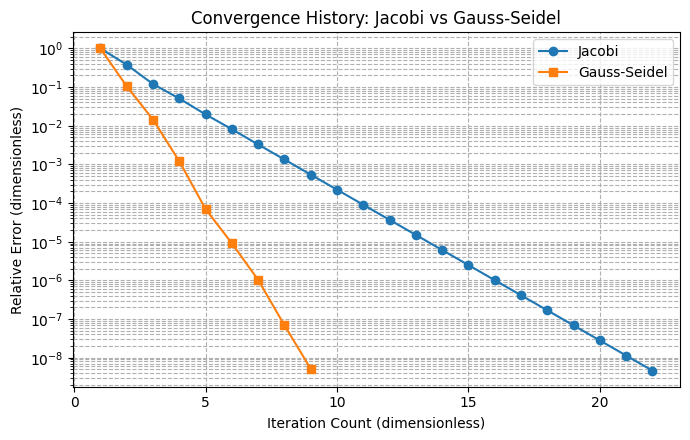

In [11]:
A = np.array([
    [6, 1, 1],
    [1, 5, 1],
    [1, 1, 4]
], dtype=float)
b = np.array([7, 10, -1], dtype=float)

x_j, it_j, hist_j = jacobi(A, b, tol=1e-8)
x_gs, it_gs, hist_gs = gauss_seidel(A, b, tol=1e-8)

assert np.allclose(A @ x_j, b, atol=1e-6)
assert np.allclose(A @ x_gs, b, atol=1e-6)

print(f"Jacobi solution:       {x_j}, iterations: {it_j}")
print(f"Gauss-Seidel solution: {x_gs}, iterations: {it_gs}")
print(f"Gauss-Seidel is roughly {it_j / it_gs:.2f}x faster than Jacobi.")

plt.figure(figsize=(7, 4.5))
plt.semilogy(range(1, it_j + 1), hist_j, 'o-', label='Jacobi')
plt.semilogy(range(1, it_gs + 1), hist_gs, 's-', label='Gauss-Seidel')
plt.xlabel("Iteration Count (dimensionless)")
plt.ylabel("Relative Error (dimensionless)")
plt.title("Convergence History: Jacobi vs Gauss-Seidel")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


### Problem 11: 1D Heat Conduction and Tridiagonal Solvers

**System Setup:**
- Discretization: $-T_{i-1} + 2 T_i - T_{i+1} = 0$ for 5 interior nodes.
- Boundaries: $T_0 = 200^\circ\text{C}, T_6 = 40^\circ\text{C}$.

$$\begin{bmatrix} 2 & -1 & 0 & 0 & 0 \\ -1 & 2 & -1 & 0 & 0 \\ 0 & -1 & 2 & -1 & 0 \\ 0 & 0 & -1 & 2 & -1 \\ 0 & 0 & 0 & -1 & 2 \end{bmatrix} \begin{bmatrix} T_1 \\ T_2 \\ T_3 \\ T_4 \\ T_5 \end{bmatrix} = \begin{bmatrix} 200 \\ 0 \\ 0 \\ 0 \\ 40 \end{bmatrix}$$

**Physical Note:** Steady 1D conduction without heat generation obeys $d^2 T / dx^2 = 0$, producing a linear temperature profile.


In [12]:
A = np.array([
    [2, -1, 0, 0, 0],
    [-1, 2, -1, 0, 0],
    [0, -1, 2, -1, 0],
    [0, 0, -1, 2, -1],
    [0, 0, 0, -1, 2]
], dtype=float)
b = np.array([200, 0, 0, 0, 40], dtype=float)

x_thomas = thomas(A, b)
x_numpy = np.linalg.solve(A, b)

ab = np.zeros((3, 5))
ab[0, 1:] = -1
ab[1, :] = 2
ab[2, :-1] = -1
x_banded = scipy.linalg.solve_banded((1, 1), ab, b)

assert np.allclose(x_thomas, x_numpy)
assert np.allclose(x_thomas, x_banded)
assert np.allclose(A @ x_thomas, b)

print(f"Thomas solution (°C):        {x_thomas}")
print(f"np.linalg.solve (°C):        {x_numpy}")
print(f"solve_banded solution (°C):  {x_banded}")


Thomas solution (°C):        [173.33333333 146.66666667 120.          93.33333333  66.66666667]
np.linalg.solve (°C):        [173.33333333 146.66666667 120.          93.33333333  66.66666667]
solve_banded solution (°C):  [173.33333333 146.66666667 120.          93.33333333  66.66666667]


### Problem 12: Flowsheet Balance with Recycle Stream

**System Setup:**
- Unknowns: $(M, P, U, R, W)$ in kg/h.
- Fresh feed: $F = 1000\text{ kg/h}$.

**Balances:**
1. Mixer balance: $M - R = 1000 \implies 1 M + 0 P + 0 U - 1 R + 0 W = 1000$
2. Reactor split 1: $P = 0.60 M \implies -0.60 M + 1 P + 0 U + 0 R + 0 W = 0$
3. Reactor split 2: $U = 0.40 M \implies -0.40 M + 0 P + 1 U + 0 R + 0 W = 0$
4. Separator split 1: $R = 0.75 U \implies 0 M + 0 P - 0.75 U + 1 R + 0 W = 0$
5. Separator split 2: $W = 0.25 U \implies 0 M + 0 P - 0.25 U + 0 R + 1 W = 0$

$$\begin{bmatrix} 1 & 0 & 0 & -1 & 0 \\ -0.60 & 1 & 0 & 0 & 0 \\ -0.40 & 0 & 1 & 0 & 0 \\ 0 & 0 & -0.75 & 1 & 0 \\ 0 & 0 & -0.25 & 0 & 1 \end{bmatrix} \begin{bmatrix} M \\ P \\ U \\ R \\ W \end{bmatrix} = \begin{bmatrix} 1000 \\ 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$$


In [13]:
A = np.array([
    [1.0, 0.0, 0.0, -1.0, 0.0],
    [-0.60, 1.0, 0.0, 0.0, 0.0],
    [-0.40, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, -0.75, 1.0, 0.0],
    [0.0, 0.0, -0.25, 0.0, 1.0]
])
b = np.array([1000.0, 0.0, 0.0, 0.0, 0.0])

x = np.linalg.solve(A, b)
M, P, U, R, W = x

assert np.allclose(A @ x, b)
assert np.isclose(P + W, 1000.0)

print(f"Flow rates (kg/h): M = {M:.2f}, P = {P:.2f}, U = {U:.2f}, R = {R:.2f}, W = {W:.2f}")
print(f"Overall mass closure (P + W = F): {P + W:.2f} kg/h")
print(f"Recycle ratio R/F: {R / 1000.0:.4f}")
print(f"Internal flow ratio M/F: {M / 1000.0:.4f}")
print("Equipment Sizing Note: Reactor/mixer equipment must be sized for internal flow M (1428.57 kg/h), which is 42.86% larger than fresh feed F.")


Flow rates (kg/h): M = 1428.57, P = 857.14, U = 571.43, R = 428.57, W = 142.86
Overall mass closure (P + W = F): 1000.00 kg/h
Recycle ratio R/F: 0.4286
Internal flow ratio M/F: 1.4286
Equipment Sizing Note: Reactor/mixer equipment must be sized for internal flow M (1428.57 kg/h), which is 42.86% larger than fresh feed F.


### Problem 13: Hilbert Matrix Ill-Conditioning and Precision Loss

**System Setup:**
- $n \times n$ Hilbert matrix $H_{ij} = \frac{1}{i + j - 1}$.
- Manufactured problem: $x_{true} = [1, 1, \dots, 1]^T$, $b = H x_{true}$.
- Matrix dimensions: $n \in [4, 6, 8, 10, 12]$.


  n |    cond(H) |  max_error |  residual_norm | digits_left
----------------------------------------------------------
  4 |   1.55e+04 |   6.55e-14 |       0.00e+00 |       11.81
  6 |   1.50e+07 |   2.39e-10 |       5.21e-16 |        8.83
  8 |   1.53e+10 |   1.19e-07 |       2.72e-16 |        5.82
 10 |   1.60e+13 |   1.69e-04 |       5.66e-16 |        2.80
 12 |   1.75e+16 |   6.96e-01 |       6.38e-16 |       -0.24
Diagnosis: At n=12, cond(H) ~ 1e16 reaches 1/eps_mach, leaving ~0 correct digits in solution x.
Residual norm remains near machine precision (~1e-16) regardless of n, hiding the severe error.


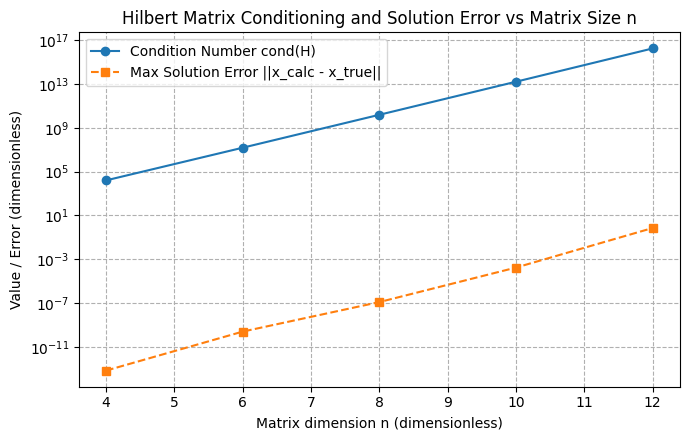

In [14]:
n_vals = [4, 6, 8, 10, 12]
cond_list = []
max_err_list = []

print(f"{'n':>3} | {'cond(H)':>10} | {'max_error':>10} | {'residual_norm':>14} | {'digits_left':>11}")
print("-" * 58)

for n in n_vals:
    H = scipy.linalg.hilbert(n)
    x_true = np.ones(n)
    b = H @ x_true
    x_calc = np.linalg.solve(H, b)
    
    cond_H = np.linalg.cond(H)
    max_err = np.max(np.abs(x_calc - x_true))
    res_norm = np.linalg.norm(H @ x_calc - b)
    digits_left = 16 - np.log10(cond_H)
    
    cond_list.append(cond_H)
    max_err_list.append(max_err)
    
    print(f"{n:3d} | {cond_H:10.2e} | {max_err:10.2e} | {res_norm:14.2e} | {digits_left:11.2f}")

plt.figure(figsize=(7, 4.5))
plt.semilogy(n_vals, cond_list, 'o-', label='Condition Number cond(H)')
plt.semilogy(n_vals, max_err_list, 's--', label='Max Solution Error ||x_calc - x_true||')
plt.xlabel("Matrix dimension n (dimensionless)")
plt.ylabel("Value / Error (dimensionless)")
plt.title("Hilbert Matrix Conditioning and Solution Error vs Matrix Size n")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

print("Diagnosis: At n=12, cond(H) ~ 1e16 reaches 1/eps_mach, leaving ~0 correct digits in solution x.")
print("Residual norm remains near machine precision (~1e-16) regardless of n, hiding the severe error.")
